# High-Performance CNN (99.41% Accuracy)
This project presents a deep CNN trained on the MNIST handwritten digit dataset, **achieving 99.33% test accuracy**. The result was enabled by a tuned CNN architecture and Early Stopping to prevent overfitting and optimize performance.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


# Data Preparation
The raw MNIST dataset was loaded directly from the provided Kaggle input files. The images and labels, which were in a binary format, were converted into NumPy arrays. To prepare the data for the CNN, two key preprocessing steps were performed:

- **Normalization**: Pixel values were scaled from their original range of 0-255 to a new range of 0-1 by dividing by 255. This improves model training stability.

- **Reshaping**: The images were reshaped from (28, 28) to (28, 28, 1) to add a channel dimension, which is a requirement for Keras's Conv2D layers.

In [2]:
import numpy as np

def read_idx3_ubyte(file_path):
    with open(file_path, 'rb') as f:
     
        f.read(4)  
        num_images = int.from_bytes(f.read(4), 'big')
        num_rows = int.from_bytes(f.read(4), 'big')
        num_cols = int.from_bytes(f.read(4), 'big')

      
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num_images, num_rows, num_cols)

def read_idx1_ubyte(file_path):
    with open(file_path, 'rb') as f:
       
        f.read(4)  
        num_labels = int.from_bytes(f.read(4), 'big')

        return np.frombuffer(f.read(), dtype=np.uint8)

In [3]:
# Define file paths
train_images_path = '/kaggle/input/mnist-dataset/train-images.idx3-ubyte'
train_labels_path = '/kaggle/input/mnist-dataset/train-labels.idx1-ubyte'
test_images_path = '/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte'
test_labels_path = '/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte'

# Load the data
X_train, y_train = read_idx3_ubyte(train_images_path), read_idx1_ubyte(train_labels_path)
X_test, y_test = read_idx3_ubyte(test_images_path), read_idx1_ubyte(test_labels_path)

# Print shapes to confirm data is loaded correctly
print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

Original X_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original X_test shape: (10000, 28, 28)
Original y_test shape: (10000,)


In [4]:
X_train = X_train / 255
X_test = X_test / 255

# CNN Model
The model is a sequential CNN with multiple convolutional and max-pooling layers to extract features from the images. It concludes with fully connected (Dense) layers for classification.

- **Convolutional Blocks**: The model uses several Conv2D layers with relu activation to detect features, followed by MaxPooling2D layers to downsample the feature maps and reduce computational load.

- **Flatten Layer**: The output from the convolutional layers is flattened into a one-dimensional vector.

- **Dense Layers**: Two dense layers with relu activation and Dropout(0.4) were used to perform the final classification and prevent overfitting.

- **Output Layer**: A final dense layer with 10 units and a softmax activation outputs the probability for each of the 10 possible digits.

In [5]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

2025-09-20 19:46:41.979566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758397602.180307      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758397602.238686      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


*Model Architecture*

In [6]:
model = Sequential()

model.add(Conv2D(256, (3,3), activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(128, (3,3), activation='relu'))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1758397616.328463      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,010 (2.01 MB)

 Trainable params: 528,010 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training and Performance Analysis
The model was trained for a maximum of 500 epochs using the Adam optimizer and sparse_categorical_crossentropy loss. An EarlyStopping callback was used to monitor the val_loss with a patience of 10 and a min_delta of 0.001.

- **Training Progression**: The training logs and accuracy/loss graphs show a rapid increase in accuracy and a sharp decrease in loss during the initial epochs.

- **Early Stopping**: The model training was automatically stopped after 14 epochs, as the validation loss did not improve significantly for 10 consecutive epochs. The best model weights were restored from Epoch 4, which had the lowest validation loss of 0.0234.

- **Final Accuracy**: The final model's performance on the test set, measured after restoring the best weights, was 99.33%. This confirms that the model is robust and has excellent generalization capabilities.

In [9]:
history = model.fit(X_train, y_train, epochs=500, batch_size=36, validation_data=(X_test, y_test),
                     callbacks=[EarlyStopping(
    monitor="val_loss",
    patience= 10,
    restore_best_weights=True,
    verbose=1,
    min_delta= 0.001
)])

Epoch 1/500


I0000 00:00:1758397621.645294      58 service.cc:148] XLA service 0x7e9c1800fb50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758397621.646176      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758397622.069713      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


  24/1667 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1237 - loss: 2.2906

I0000 00:00:1758397625.741204      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1667/1667 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.7854 - loss: 0.6330 - val_accuracy: 0.9867 - val_loss: 0.0485
Epoch 2/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9766 - loss: 0.0927 - val_accuracy: 0.9882 - val_loss: 0.0360
Epoch 3/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9848 - loss: 0.0637 - val_accuracy: 0.9902 - val_loss: 0.0325
Epoch 4/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9880 - loss: 0.0485 - val_accuracy: 0.9922 - val_loss: 0.0343
Epoch 5/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9886 - loss: 0.0442 - val_accuracy: 0.9904 - val_loss: 0.0336
Epoch 6/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9911 - loss: 0.0358 - val_accuracy: 0.9913 - val_loss: 0.0300
Epoch 7/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9920 - loss: 0.0315 - val_accuracy: 0.9918 - val_loss: 0.0300
Epoch 8/500
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9922 - loss: 0.03

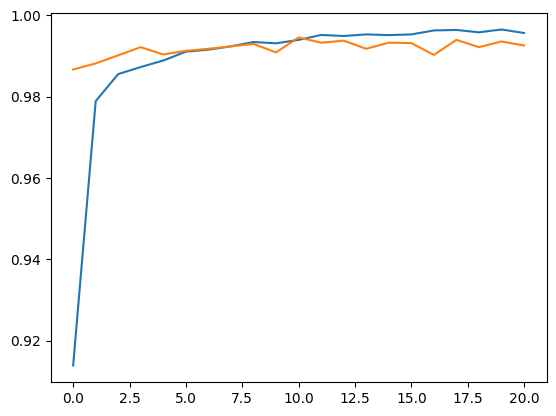

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

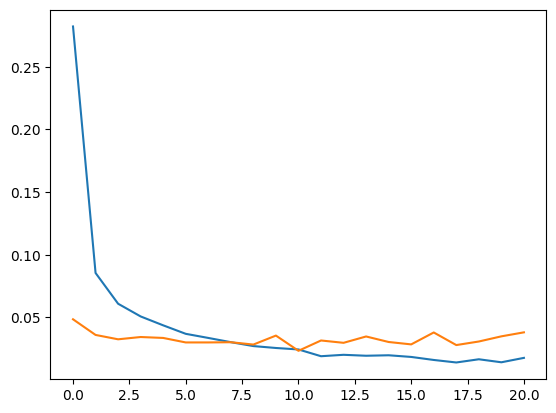

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [12]:
model_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [13]:
model_pred = model_prob.argmax(axis=1)

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, model_pred)

0.9946

# Conclusion
This project demonstrates that a well-designed CNN, combined with EarlyStopping, can efficiently achieve 99.41% test accuracy on the MNIST dataset.